In [ ]:
import pandas as pd

df = pd.read_csv('part_4_text_dataset.csv')

df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_shuffled.to_csv('course_project_text_dataset.csv', index=False, encoding='utf-8')


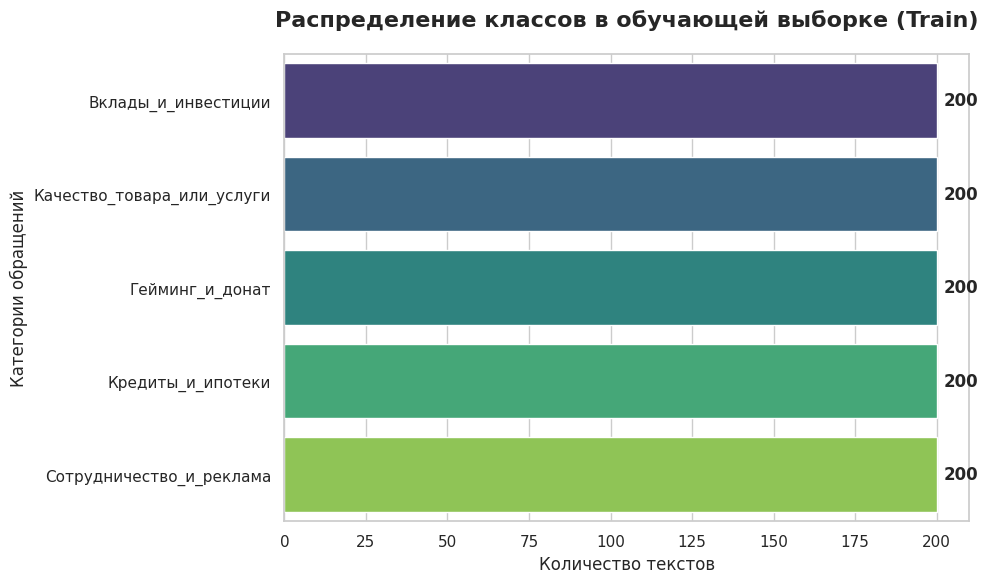

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv('train.csv')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df_train,
    y='label',
    hue='label',
    order=df_train['label'].value_counts().index,
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=12, weight='bold')

plt.title('Распределение классов в обучающей выборке (Train)', fontsize=16, pad=20, weight='bold')
plt.xlabel('Количество текстов', fontsize=12)
plt.ylabel('Категории обращений', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df_train = pd.read_csv('train.csv')

word_counts = df_train['text'].astype(str).apply(lambda x: len(x.split()))

min_len = word_counts.min()
mean_len = round(word_counts.mean(), 1)
max_len = word_counts.max()

print(f"a) Минимальная длина: {min_len} слов(о)")
print(f"b) Средняя длина: {mean_len} слов(а)")
print(f"c) Максимальная длина: {max_len} слов")


a) Минимальная длина: 2 слов(о)
b) Средняя длина: 20.1 слов(а)
c) Максимальная длина: 97 слов


In [ ]:
import pandas as pd
import re

df = pd.read_csv('train.csv')

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^а-яё ]', '', text)
    text = ' '.join(text.split())
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("--- 1. Очистка текста (Примеры результатов) ---")
for i in range(3):
    print(f"Пример {i+1}")
    print(f"До:    {df['text'].iloc[i]}")
    print(f"После: {df['clean_text'].iloc[i]}")
    print("-" * 50)


--- 1. Очистка текста (Примеры результатов) ---
Пример 1
До:    что такое капитализация процентов
После: что такое капитализация процентов
--------------------------------------------------
Пример 2
До:    Ваши мастера побелили потолок, но краска легла с разводами. Теперь потолок выглядит хуже, чем до ремонта.
После: ваши мастера побелили потолок но краска легла с разводами теперь потолок выглядит хуже чем до ремонта
--------------------------------------------------
Пример 3
До:    Роутер, который вы установили при подключении, постоянно теряет сигнал и перезагружается самостоятельно каждые несколько часов.
После: роутер который вы установили при подключении постоянно теряет сигнал и перезагружается самостоятельно каждые несколько часов
--------------------------------------------------


In [ ]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 66.4 MB/s eta 0:00:00


In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

def lemmatize_text(text):
    """
    Разбивает текст на слова и каждое слово приводит к начальной форме.
    """
    words = text.split()
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return ' '.join(lemmas)

df['lemmas'] = df['clean_text'].apply(lemmatize_text)

print("--- 2. Лемматизация (Примеры результатов) ---")
for i in range(3):
    print(f"Пример {i+1}")
    print(f"До (очищенный): {df['clean_text'].iloc[i]}")
    print(f"После (леммы):  {df['lemmas'].iloc[i]}")
    print("-" * 50)

--- 2. Лемматизация (Примеры результатов) ---
Пример 1
До (очищенный): что такое капитализация процентов
После (леммы):  что такой капитализация процент
--------------------------------------------------
Пример 2
До (очищенный): ваши мастера побелили потолок но краска легла с разводами теперь потолок выглядит хуже чем до ремонта
После (леммы):  ваш мастер побелить потолок но краска лечь с развод теперь потолок выглядеть плохой чем до ремонт
--------------------------------------------------
Пример 3
До (очищенный): роутер который вы установили при подключении постоянно теряет сигнал и перезагружается самостоятельно каждые несколько часов
После (леммы):  роутер который вы установить при подключение постоянно терять сигнал и перезагружаться самостоятельно каждый несколько час
--------------------------------------------------


In [ ]:
!pip install wordcloud

Топ-10 самых частых слов:
в: 474
и: 433
я: 416
на: 386
не: 296
хотеть: 279
с: 272
для: 217
это: 197
что: 190


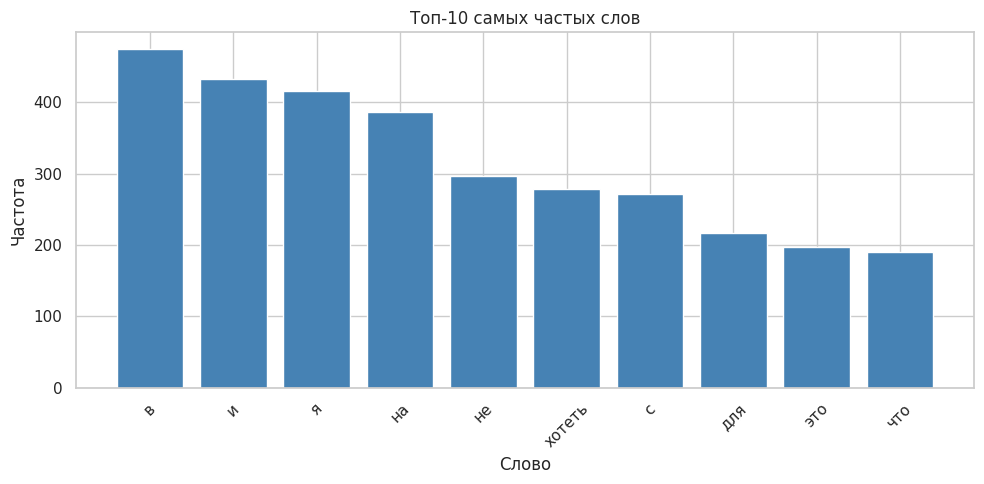

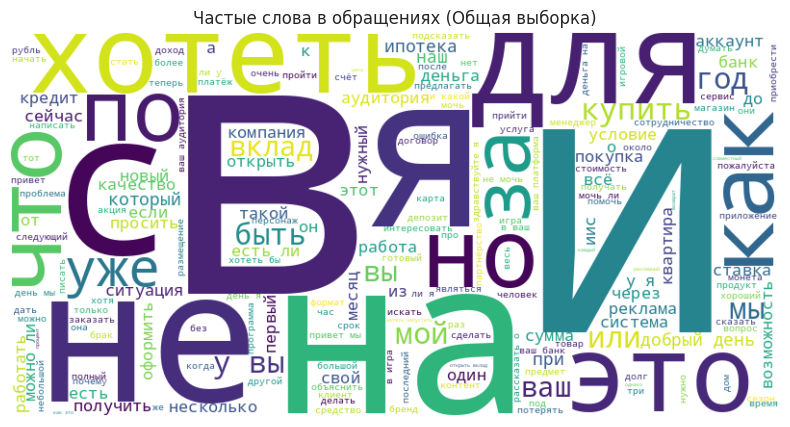

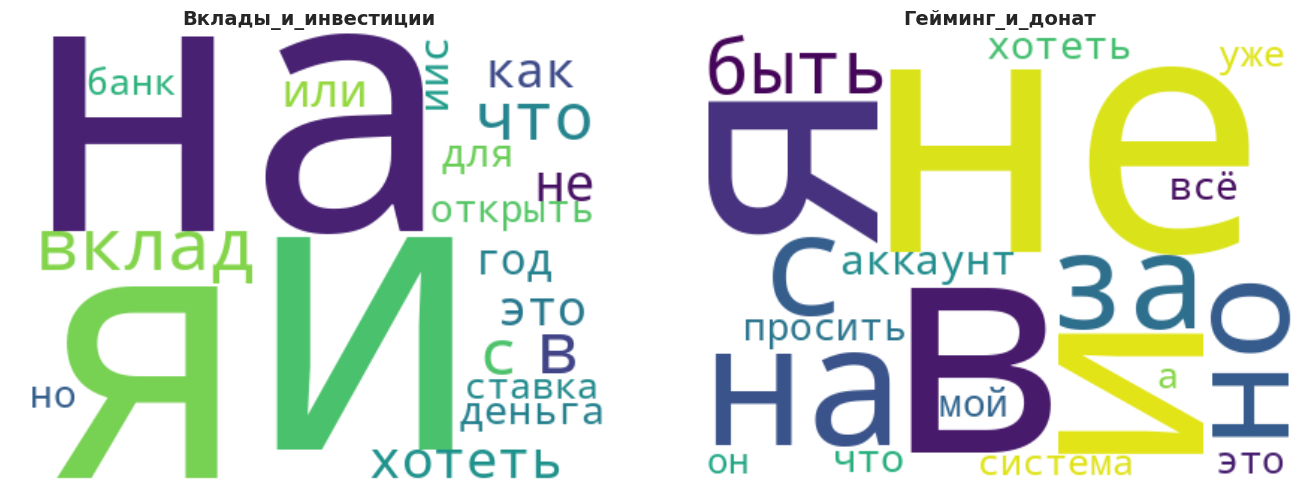

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join(df['lemmas']).split()
word_counts = Counter(all_words)

print("Топ-10 самых частых слов:")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")

top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Топ-10 самых частых слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

all_text = ' '.join(df['lemmas'])
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в обращениях (Общая выборка)')
plt.show()

category_1 = 'Вклады_и_инвестиции'
category_2 = 'Гейминг_и_донат'

text_1 = ' '.join(df[df['label'] == category_1]['lemmas'])
wc_1 = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(text_1)

text_2 = ' '.join(df[df['label'] == category_2]['lemmas'])
wc_2 = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(text_2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wc_1, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title(category_1, fontsize=14, weight='bold')

axes[1].imshow(wc_2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title(category_2, fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('russian'))

print("Примеры стоп-слов:", list(stop_words)[:20])

def remove_stopwords(text, stop_words):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

df['no_stopwords'] = df['lemmas'].apply(lambda x: remove_stopwords(x, stop_words))

print("\n--- 4. Удаление стоп-слов (Примеры результатов) ---")
for i in range(3):
    print(f"Пример {i+1}")
    print(f"До (с шумом):   {df['lemmas'].iloc[i]}")
    print(f"После (чистый): {df['no_stopwords'].iloc[i]}")
    print("-" * 50)


Примеры стоп-слов: ['за', 'только', 'тем', 'моя', 'здесь', 'под', 'теперь', 'всегда', 'мой', 'он', 'вас', 'чуть', 'они', 'этого', 'от', 'ты', 'есть', 'без', 'про', 'эту']

--- 4. Удаление стоп-слов (Примеры результатов) ---
Пример 1
До (с шумом):   что такой капитализация процент
После (чистый): капитализация процент
--------------------------------------------------
Пример 2
До (с шумом):   ваш мастер побелить потолок но краска лечь с развод теперь потолок выглядеть плохой чем до ремонт
После (чистый): ваш мастер побелить потолок краска лечь развод потолок выглядеть плохой ремонт
--------------------------------------------------
Пример 3
До (с шумом):   роутер который вы установить при подключение постоянно терять сигнал и перезагружаться самостоятельно каждый несколько час
После (чистый): роутер который установить подключение постоянно терять сигнал перезагружаться самостоятельно каждый несколько час
--------------------------------------------------


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['no_stopwords'])

feature_names = vectorizer.get_feature_names_out()
print(f"Размер словаря: {len(feature_names)} слов")

print("\nПример слов из словаря:")
print(feature_names[:30])

print("\n--- Пример вектора для первого текста ---")
print(f"Текст: {df['no_stopwords'].iloc[0]}")
print(f"Вектор:\n{tfidf_matrix[0].toarray()}")


Размер словаря: 3044 слов

Пример слов из словаря:
['абонемент' 'абонентский' 'абсолютно' 'автокредит' 'автомат'
 'автоматизация' 'автоматически' 'автоматический' 'автомобиль' 'автоответ'
 'автопополнение' 'автор' 'авторизовать' 'авторский' 'автофокус'
 'автошкола' 'агент' 'агентство' 'агрегат' 'агрессивный' 'агробизнес'
 'агротех' 'адрес' 'айтишник' 'аккаунт' 'аккредитация' 'аккредитовать'
 'аксессуар' 'акт' 'актив']

--- Пример вектора для первого текста ---
Текст: капитализация процент
Вектор:
[[0. 0. 0. ... 0. 0. 0.]]


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def search_texts(query, vectorizer, tfidf_matrix, texts, top_n=3):
    """
    Ищет top_n текстов, наиболее похожих на запрос.
    """
    query = clean_text(query)
    query = lemmatize_text(query)
    query_vec = vectorizer.transform([query])

    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

    top_indices = similarities.argsort()[-top_n:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'Текст': texts.iloc[idx],
            'Похожесть': similarities[idx]
        })

    return results

query = "проблема с донатом в игре"
results = search_texts(query, vectorizer, tfidf_matrix, df['text'], top_n=3)

print(f"Поисковый запрос: '{query}'")
print(f"Найдено {len(results)} наиболее похожих отзывов:\n")

for i, res in enumerate(results, 1):
    print(f"{i}. Похожесть: {res['Похожесть']:.8f}")
    print(f"   Текст: {res['Текст']}\n")


Поисковый запрос: 'проблема с донатом в игре'
Найдено 3 наиболее похожих отзывов:

1. Похожесть: 0.55359940
   Текст: Не пришёл донат

2. Похожесть: 0.46333109
   Текст: Донат не зачислился

3. Похожесть: 0.42875167
   Текст: не работает кнопка доната



In [ ]:
df.to_csv('train_processed.csv', index=False, encoding='utf-8')
print("Ура! Все изменения успешно записаны в файл 'train_processed.csv'!")


Ура! Все изменения успешно записаны в файл 'train_processed.csv'!


In [ ]:
import pandas as pd
import re
import pymorphy3
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words('russian'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё ]', '', text)
    return ' '.join(text.split())

def lemmatize_text(text):
    words = text.split()
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return ' '.join(lemmas)

def remove_stopwords(text, stop_words):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

df_train = pd.read_csv('train.csv')
df_test_blind = pd.read_csv('test.csv')
df_test_labels = pd.read_csv('test_labeled.csv')

print("Шаг 1: Очистка текстовых файлов...")
df_train['no_stopwords'] = df_train['text'].apply(clean_text).apply(lemmatize_text).apply(lambda x: remove_stopwords(x, stop_words))
df_test_blind['no_stopwords'] = df_test_blind['text'].apply(clean_text).apply(lemmatize_text).apply(lambda x: remove_stopwords(x, stop_words))
df_test_labels['no_stopwords'] = df_test_labels['text'].apply(clean_text).apply(lemmatize_text).apply(lambda x: remove_stopwords(x, stop_words))

X_train = df_train['no_stopwords'].astype(str)
y_train = df_train['label']

vectorizer = TfidfVectorizer(max_features=3000)
X_train_vectors = vectorizer.fit_transform(X_train)

model = LogisticRegression(random_state=42)
model.fit(X_train_vectors, y_train)
print("🎉 Модель успешно обучена!")

print("\nШаг 2: ИИ делает предсказания для слепого файла 'test.csv'...")
X_blind_vectors = vectorizer.transform(df_test_blind['no_stopwords'].astype(str))
df_test_blind['predicted_label'] = model.predict(X_blind_vectors)

df_test_blind.to_csv('test_predictions.csv', index=False, encoding='utf-8')
print("🔥 Результаты предсказаний ИИ сохранены в файл 'test_predictions.csv'!")

X_labels_vectors = vectorizer.transform(df_test_labels['no_stopwords'].astype(str))
y_test_real = df_test_labels['label']
y_pred = model.predict(X_labels_vectors)

accuracy = accuracy_score(y_test_real, y_pred)
print(f"\n🎯 Общая точность вашей модели (Accuracy): {accuracy * 100:.2f}%\n")

print("--- Подробный отчет по классам ---")
print(classification_report(y_test_real, y_pred))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Шаг 1: Очистка текстовых файлов...
🎉 Модель успешно обучена!

Шаг 2: ИИ делает предсказания для слепого файла 'test.csv'...
🔥 Результаты предсказаний ИИ сохранены в файл 'test_predictions.csv'!

🎯 Общая точность вашей модели (Accuracy): 94.95%

--- Подробный отчет по классам ---
                            precision    recall  f1-score   support

       Вклады_и_инвестиции       1.00      1.00      1.00        19
           Гейминг_и_донат       0.83      1.00      0.91        20
Качество_товара_или_услуги       1.00      0.76      0.86        21
         Кредиты_и_ипотеки       0.95      1.00      0.97        19
  Сотрудничество_и_реклама       1.00      1.00      1.00        20

                  accuracy                           0.95        99
                 macro avg       0.96      0.95      0.95        99
              weighted avg       0.96      0.95      0.95        99

